Source: https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa
Doesn't include noise like the original. May not work for large number of qubits.

In [135]:
from qiskit_aer import AerSimulator
backend = AerSimulator()

In [136]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.

from qiskit_aer.noise import NoiseModel

# Alternatively, load a fake backend with generic properties and define a simulator.


# noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator()
sampler_sim = BackendSamplerV2(backend=backend_sim)

# You could also define a simulator-based sampler using a generic backend:
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

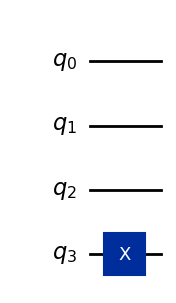

In [137]:
from qiskit import QuantumCircuit
import numpy as np


def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """

    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance.
        return qc_dj

    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:

    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj

    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created. They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
        qc_dj = add_cx(qc_dj, f"{state:0b}")

    # qc_dj.barrier()

    return qc_dj


n = 3  # number of input qubits

oracle = dj_function(n)

display(oracle.draw("mpl"))

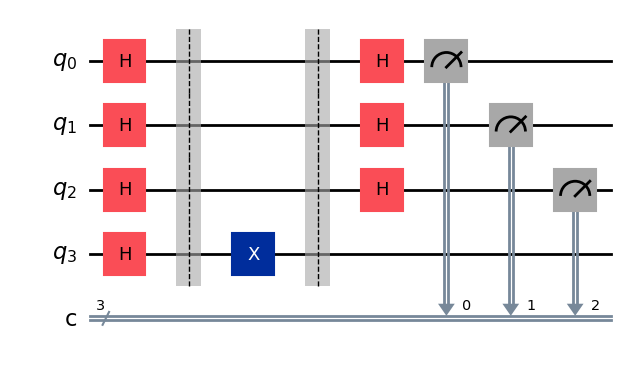

In [138]:
# Step 1: Map the problem

# requires {q[0,n) : nor -> |0>}
# requires {q[n] : nor -> |1>}
# requires balanced(oracle) || constant(oracle)
# ensures constant(oracle) <=> q[0,n) : EN -> |0>
# ensures balanced(oracle) => at least one qubit must be 1?

qc_dj= QuantumCircuit(n+1,n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))
qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [139]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

In [140]:
# Step 3: Run the job on a real quantum computer

#job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [141]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)

if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'000': 1}
constant
